In [1]:
import pandas as pd
import numpy as np

In [5]:
from pathlib import Path
import pandas as pd

PROJECT_PATH = Path(r"C:\Projects\Enterprise AI Analytics Platform for Customer Complaints")

MYSQL_READY_FILE = PROJECT_PATH / "data" / "processed" / "complaints_mysql_ready.csv"

In [9]:
df = pd.read_csv(
    MYSQL_READY_FILE,
    usecols=["complaint_id", "consumer_complaint_narrative"],
    nrows=100000,
    low_memory=False
)

In [11]:
print(df.shape)

(100000, 2)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   consumer_complaint_narrative  100000 non-null  object
 1   complaint_id                  100000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.5+ MB


In [15]:
df.isnull().sum()

consumer_complaint_narrative    0
complaint_id                    0
dtype: int64

In [23]:
df.sample(10, random_state=42)

,consumer_complaint_narrative,complaint_id
75721,Not Provided,23648076
80184,Not Provided,23651204
19864,Not Provided,21255432
76699,Not Provided,23629432
92991,Not Provided,23659274
76434,Not Provided,23604407
84004,Not Provided,23596293
80917,Not Provided,23652569
60767,Not Provided,23196574
50074,Not Provided,22149624


In [25]:
df["text_length"] = df["consumer_complaint_narrative"].str.len()

df["text_length"].describe()

count    100000.000000
mean         48.503080
std         305.655021
min          12.000000
25%          12.000000
50%          12.000000
75%          12.000000
max       20035.000000
Name: text_length, dtype: float64

In [27]:
df.nlargest(
    20,
    "text_length"
)[["complaint_id", "text_length", "consumer_complaint_narrative"]]

,complaint_id,text_length,consumer_complaint_narrative
21729,21486018,20035,Subject : AMENDED FORMAL CFPB COMPLAINT | WITH...
56183,22596398,16272,"XX/XX/XXXX Bank of America , N.A .\n\nAttentio..."
93888,14914399,15746,I am submitting a Consumer Financial Protectio...
97077,19887074,14775,"COMPANY : Planet Home Lending , LLC ISSUE : Mo..."
29,21707839,11809,XX/XX/XXXX From : XXXX XXXX XXXX XXXX XXXX XXX...
36627,21712294,10645,UPDATED CFPB RESPONSE ( STRONG VERSION ) Consu...
15554,21163019,9351,I am writing to complain about Onity Mortgage ...
17415,21192538,8751,Capital One Case Number : XXXX Account Type : ...
41101,21734924,8580,"b""XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX..."
17859,21195829,8246,"Good Afternoon, Please see the XXXX letters be..."


In [29]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"xxxx", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["cleaned_text"] = df["consumer_complaint_narrative"].apply(clean_text)

df[["consumer_complaint_narrative", "cleaned_text"]].head()

,consumer_complaint_narrative,cleaned_text
0,I purchased a vehicle from a company called ca...,i purchased a vehicle from a company called ca...
1,I recently logged into my Mohela and XXXX acco...,i recently logged into my mohela and account t...
2,I am in the Public Service Loan Forgiveness Pr...,i am in the public service loan forgiveness pr...
3,Not Provided,not provided
4,On XX/XX/scrub> 2025 my credit scored dropped ...,on xx xx scrub my credit scored dropped points...


In [31]:
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [33]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["cleaned_text"].apply(word_tokenize)

df[["cleaned_text", "tokens"]].head()

,cleaned_text,tokens
0,i purchased a vehicle from a company called ca...,"[i, purchased, a, vehicle, from, a, company, c..."
1,i recently logged into my mohela and account t...,"[i, recently, logged, into, my, mohela, and, a..."
2,i am in the public service loan forgiveness pr...,"[i, am, in, the, public, service, loan, forgiv..."
3,not provided,"[not, provided]"
4,on xx xx scrub my credit scored dropped points...,"[on, xx, xx, scrub, my, credit, scored, droppe..."


In [35]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [37]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print(list(stop_words)[:20])

['above', "it'd", 'no', 'doing', 'shan', "doesn't", 'as', "wouldn't", 'me', "you'll", 'mustn', 'being', 'most', 'up', 'against', "i'll", 'be', "we've", 'hers', 'a']


In [39]:
df["filtered_tokens"] = df["tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

df[["tokens", "filtered_tokens"]].head()

,tokens,filtered_tokens
0,"[i, purchased, a, vehicle, from, a, company, c...","[purchased, vehicle, company, called, car, cre..."
1,"[i, recently, logged, into, my, mohela, and, a...","[recently, logged, mohela, account, find, extr..."
2,"[i, am, in, the, public, service, loan, forgiv...","[public, service, loan, forgiveness, program, ..."
3,"[not, provided]",[provided]
4,"[on, xx, xx, scrub, my, credit, scored, droppe...","[xx, xx, scrub, credit, scored, dropped, point..."


In [41]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [43]:
df["stemmed_tokens"] = df["filtered_tokens"].apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)

df[["filtered_tokens", "stemmed_tokens"]].head()

,filtered_tokens,stemmed_tokens
0,"[purchased, vehicle, company, called, car, cre...","[purchas, vehicl, compani, call, car, credit, ..."
1,"[recently, logged, mohela, account, find, extr...","[recent, log, mohela, account, find, extra, ac..."
2,"[public, service, loan, forgiveness, program, ...","[public, servic, loan, forgiv, program, submit..."
3,[provided],[provid]
4,"[xx, xx, scrub, credit, scored, dropped, point...","[xx, xx, scrub, credit, score, drop, point, mi..."


In [45]:
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...


True

In [46]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [49]:
df["lemmatized_tokens"] = df["filtered_tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

df[["filtered_tokens", "lemmatized_tokens"]].head()

,filtered_tokens,lemmatized_tokens
0,"[purchased, vehicle, company, called, car, cre...","[purchased, vehicle, company, called, car, cre..."
1,"[recently, logged, mohela, account, find, extr...","[recently, logged, mohela, account, find, extr..."
2,"[public, service, loan, forgiveness, program, ...","[public, service, loan, forgiveness, program, ..."
3,[provided],[provided]
4,"[xx, xx, scrub, credit, scored, dropped, point...","[xx, xx, scrub, credit, scored, dropped, point..."


In [51]:
from collections import Counter

In [53]:
word_freq = Counter()

for tokens in df["lemmatized_tokens"]:
    word_freq.update(tokens)

word_freq.most_common(20)

[('provided', 98371),
 ('xx', 8670),
 ('account', 7308),
 ('credit', 4227),
 ('payment', 2682),
 ('debt', 2519),
 ('reporting', 2006),
 ('bank', 2006),
 ('information', 1834),
 ('year', 1831),
 ('dispute', 1730),
 ('report', 1642),
 ('transaction', 1592),
 ('card', 1436),
 ('time', 1415),
 ('charge', 1345),
 ('complaint', 1343),
 ('request', 1332),
 ('balance', 1330),
 ('received', 1319)]

In [55]:
freq_df = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

freq_df

,Word,Frequency
0,provided,98371
1,xx,8670
2,account,7308
3,credit,4227
4,payment,2682
5,debt,2519
6,reporting,2006
7,bank,2006
8,information,1834
9,year,1831


In [57]:
top50_words = pd.DataFrame(
    word_freq.most_common(50),
    columns=["Word", "Frequency"]
)

top50_words

,Word,Frequency
0,provided,98371
1,xx,8670
2,account,7308
3,credit,4227
4,payment,2682
5,debt,2519
6,reporting,2006
7,bank,2006
8,information,1834
9,year,1831


In [59]:
from nltk.util import ngrams
from collections import Counter

In [61]:
bigram_counter = Counter()

for tokens in df["lemmatized_tokens"]:
    bigrams = ngrams(tokens, 2)
    bigram_counter.update(bigrams)

bigram_counter.most_common(20)

[(('xx', 'xx'), 4608),
 (('xx', 'year'), 1426),
 (('credit', 'report'), 701),
 (('credit', 'reporting'), 686),
 (('u', 'c'), 534),
 (('credit', 'card'), 508),
 (('fair', 'credit'), 425),
 (('well', 'fargo'), 425),
 (('complaint', 'regarding'), 338),
 (('alleged', 'debt'), 334),
 (('identity', 'theft'), 323),
 (('reporting', 'act'), 314),
 (('filing', 'complaint'), 312),
 (('credit', 'bureau'), 306),
 (('bank', 'america'), 305),
 (('capital', 'one'), 302),
 (('reporting', 'agency'), 299),
 (('debt', 'collection'), 288),
 (('original', 'creditor'), 279),
 (('customer', 'service'), 270)]

In [63]:
bigram_df = pd.DataFrame(
    [
        (" ".join(bigram), freq)
        for bigram, freq in bigram_counter.most_common(20)
    ],
    columns=["Bigram", "Frequency"]
)

bigram_df

,Bigram,Frequency
0,xx xx,4608
1,xx year,1426
2,credit report,701
3,credit reporting,686
4,u c,534
5,credit card,508
6,fair credit,425
7,well fargo,425
8,complaint regarding,338
9,alleged debt,334


In [65]:
trigram_counter = Counter()

for tokens in df["lemmatized_tokens"]:
    trigrams = ngrams(tokens, 3)
    trigram_counter.update(trigrams)

trigram_counter.most_common(20)

[(('xx', 'xx', 'year'), 1425),
 (('xx', 'xx', 'xx'), 578),
 (('fair', 'credit', 'reporting'), 314),
 (('credit', 'reporting', 'act'), 314),
 (('debt', 'collection', 'practice'), 224),
 (('fair', 'debt', 'collection'), 214),
 (('collection', 'practice', 'act'), 214),
 (('falsely', 'reporting', 'credit'), 213),
 (('reporting', 'act', 'fcra'), 158),
 (('credit', 'reporting', 'agency'), 158),
 (('consumer', 'financial', 'protection'), 157),
 (('filing', 'complaint', 'regarding'), 153),
 (('practice', 'act', 'fdcpa'), 142),
 (('financial', 'protection', 'bureau'), 141),
 (('date', 'xx', 'xx'), 129),
 (('account', 'xx', 'xx'), 124),
 (('consumer', 'reporting', 'agency'), 119),
 (('submitting', 'complaint', 'regarding'), 101),
 (('dated', 'xx', 'xx'), 99),
 (('credit', 'card', 'account'), 91)]

In [67]:
trigram_df = pd.DataFrame(
    [
        (" ".join(trigram), freq)
        for trigram, freq in trigram_counter.most_common(20)
    ],
    columns=["Trigram", "Frequency"]
)

trigram_df

,Trigram,Frequency
0,xx xx year,1425
1,xx xx xx,578
2,fair credit reporting,314
3,credit reporting act,314
4,debt collection practice,224
5,fair debt collection,214
6,collection practice act,214
7,falsely reporting credit,213
8,reporting act fcra,158
9,credit reporting agency,158


In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert token lists back into sentences
df["processed_text"] = df["lemmatized_tokens"].apply(lambda x: " ".join(x))

# Create TF-IDF vectors
tfidf = TfidfVectorizer(max_features=5000)

tfidf_matrix = tfidf.fit_transform(df["processed_text"])

print(tfidf_matrix.shape)

(100000, 5000)


In [71]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['aadvantage' 'aafes' 'abandon' 'abandoned' 'abandonment' 'ability' 'able'
 'abnormal' 'abound' 'abounds' 'abroad' 'abruptly' 'absence' 'absent'
 'absolute' 'absolutely' 'abuse' 'abused' 'abusive' 'accept' 'acceptable'
 'acceptance' 'accepted' 'accepting' 'access' 'accessed' 'accessibility'
 'accessible' 'accessing' 'accident' 'accidental' 'accidentally'
 'accommodate' 'accommodation' 'accompanied' 'accord' 'accordance'
 'according' 'accordingly' 'account' 'accountability' 'accountable'
 'accounted' 'accounting' 'accredited' 'accrual' 'accrue' 'accrued'
 'accruing' 'acct']


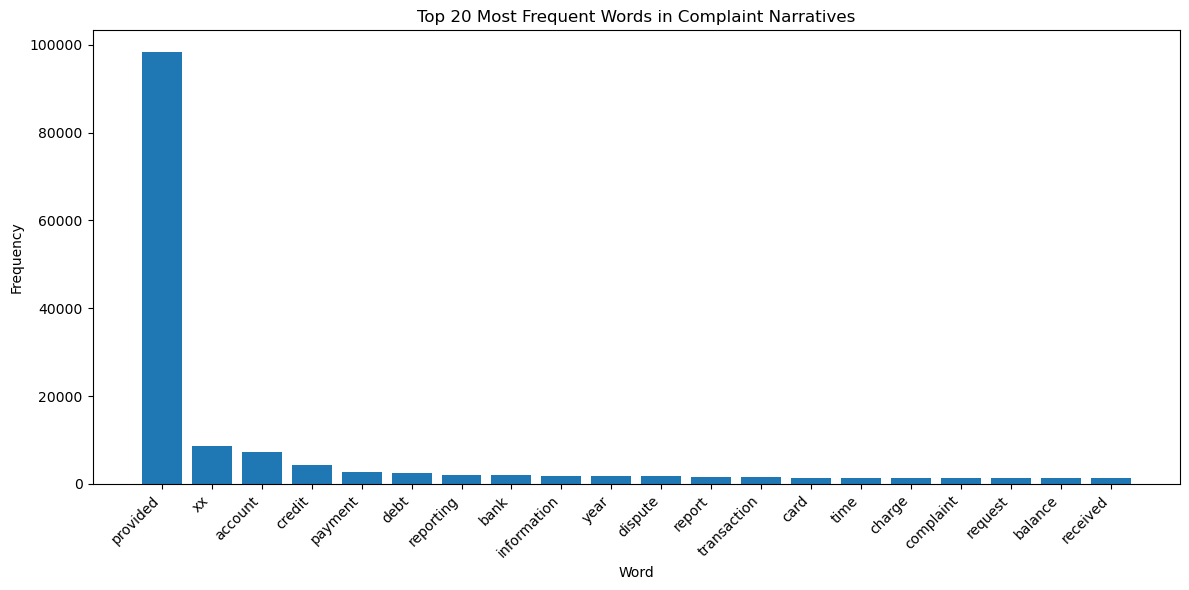

In [73]:
import matplotlib.pyplot as plt

top20_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(12, 6))
plt.bar(top20_words["Word"], top20_words["Frequency"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Most Frequent Words in Complaint Narratives")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

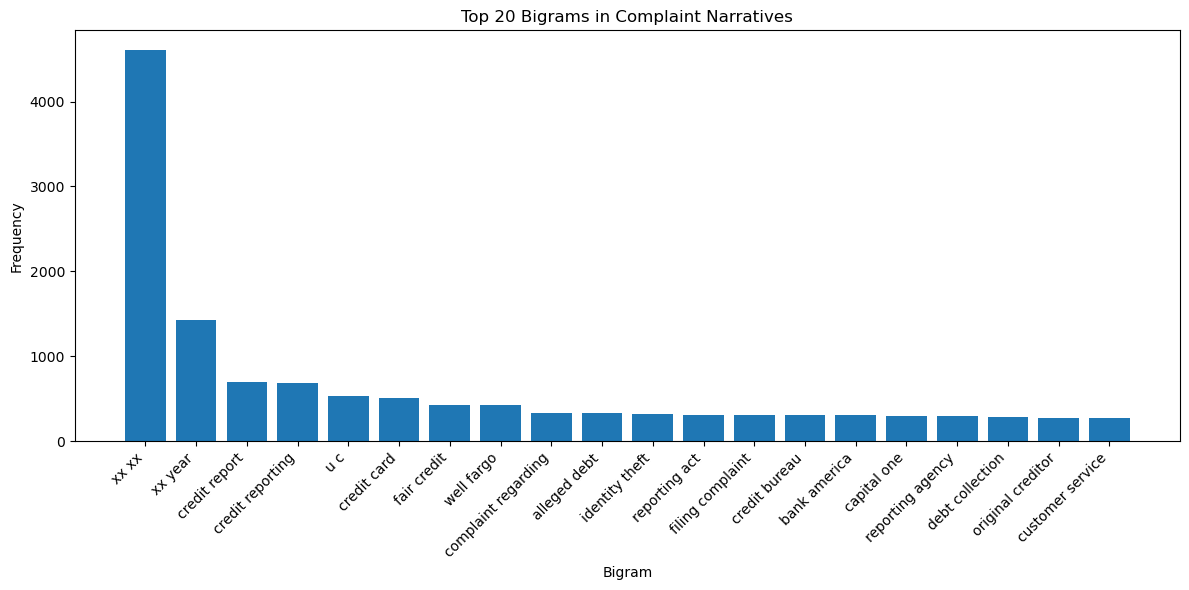

In [75]:
plt.figure(figsize=(12, 6))
plt.bar(bigram_df["Bigram"], bigram_df["Frequency"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Bigrams in Complaint Narratives")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [77]:
# Final text column for embeddings
df["final_text_for_embeddings"] = df["processed_text"]

# Remove empty rows
embedding_df = df[
    df["final_text_for_embeddings"].str.strip() != ""
][["complaint_id", "final_text_for_embeddings"]]

embedding_df.head()

,complaint_id,final_text_for_embeddings
0,10866944,purchased vehicle company called car credit we...
1,12856369,recently logged mohela account find extra accr...
2,13160260,public service loan forgiveness program submit...
3,12979646,provided
4,12972549,xx xx scrub credit scored dropped point middle...


In [79]:
embedding_df.to_csv(
    PROJECT_PATH / "data" / "processed" / "embedding_sample_100k.csv",
    index=False
)